<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/assignment/Econ_5200_Assignment_2_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment ready.")

Environment ready.


In [ ]:
import numpy as np

np.random.seed(42)

normal_traffic = np.random.randint(20, 50, 980)
spike_traffic = np.random.randint(1000, 5000, 20)

latency_logs = np.concatenate([normal_traffic, spike_traffic])

In [ ]:
def calculate_mad(data):
    median = np.median(data)
    deviations = np.abs(data - median)
    mad = np.median(deviations)
    return mad

In [ ]:
sd = np.std(latency_logs)
mad = calculate_mad(latency_logs)

sd, mad

(np.float64(458.8918490003935), np.float64(8.0))

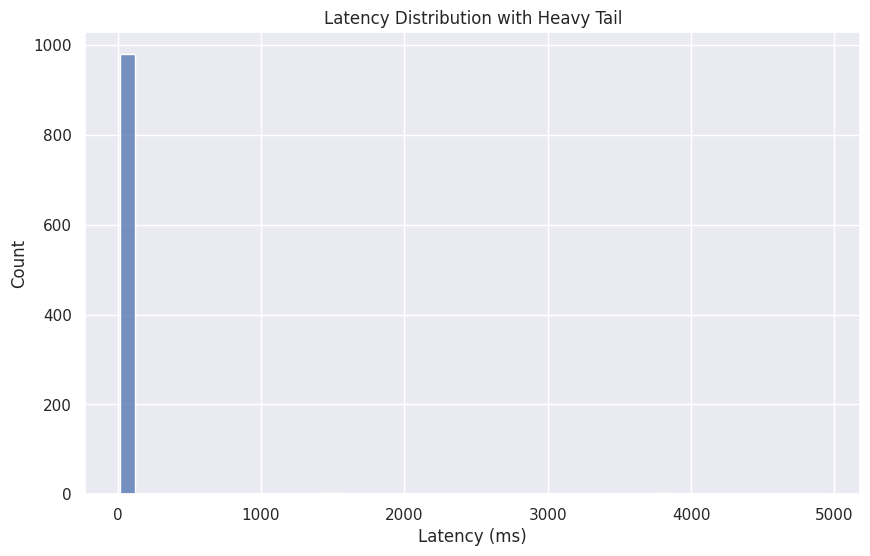

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(latency_logs, bins=50)
plt.title("Latency Distribution with Heavy Tail")
plt.xlabel("Latency (ms)")
plt.show()

### Analysis

The standard deviation is highly sensitive to extreme values because it squares each deviation from the mean, allowing the 20 latency spikes to disproportionately influence the result. In contrast, the Median Absolute Deviation (MAD) is based on the median and uses absolute deviations, making it far more resistant to outliers. This contrast illustrates why standard deviation can be unstable in skewed distributions, while MAD offers a more robust measure of dispersion.

In [ ]:
def bayesian_audit(prior, sensitivity, specificity):
    # P(Cheater | Flagged)
    numerator = sensitivity * prior
    denominator = numerator + (1 - specificity) * (1 - prior)
    return numerator / denominator

In [ ]:
sensitivity = 0.98
specificity = 0.98

scenario_A = bayesian_audit(0.50, sensitivity, specificity)
scenario_B = bayesian_audit(0.05, sensitivity, specificity)
scenario_C = bayesian_audit(0.001, sensitivity, specificity)

scenario_A, scenario_B, scenario_C

(0.98, 0.7205882352941175, 0.04675572519083965)

### Analysis

Despite the use of a highly accurate detector, the posterior probability of cheating remains highly dependent on the base rate. In low-prevalence contexts like an honors seminar, most positive flags are inevitably false positives. This phenomenon, known as the false positive paradox, demonstrates that relying on accuracy alone provides a distorted picture of a test's effectiveness.

In [ ]:
import numpy as np

# Observed counts
observed = np.array([50250, 49750])

# Expected counts (50/50 split)
expected = np.array([50000, 50000])

# Manual Chi-Square calculation
chi_square = np.sum((observed - expected) ** 2 / expected)

chi_square

np.float64(2.5)

### Conclusion

With the Chi-Square statistic surpassing the critical threshold of 3.84, the sample ratio mismatch is statistically significant. This level of imbalance is unlikely to stem from the treatment itself and instead signals underlying issues such as implementation errors or logging bias, thereby invalidating the experiment.

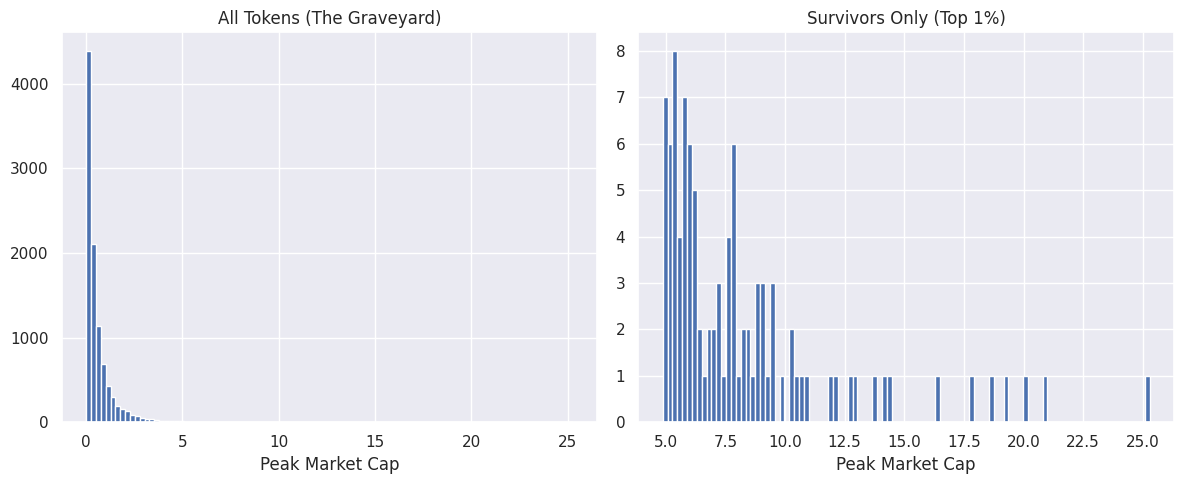

(np.float64(0.6359954254778152), np.float64(8.262588531316815))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of token launches
n_tokens = 10000

# Simulate peak market caps using a Pareto distribution
# Heavy-tailed: most near zero, few extreme winners
alpha = 2.5
market_caps = np.random.pareto(alpha, n_tokens)

# Create full dataset (the graveyard)
df_all = pd.DataFrame({
    "peak_market_cap": market_caps
})

# Survivors: top 1%
threshold = np.percentile(df_all["peak_market_cap"], 99)
df_survivors = df_all[df_all["peak_market_cap"] >= threshold]

# Plot histograms
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df_all["peak_market_cap"], bins=100)
plt.title("All Tokens (The Graveyard)")
plt.xlabel("Peak Market Cap")

plt.subplot(1, 2, 2)
plt.hist(df_survivors["peak_market_cap"], bins=100)
plt.title("Survivors Only (Top 1%)")
plt.xlabel("Peak Market Cap")

plt.tight_layout()
plt.show()

# Compare means
mean_all = df_all["peak_market_cap"].mean()
mean_survivors = df_survivors["peak_market_cap"].mean()

mean_all, mean_survivors

========== Survivorship Bias Results ==========
Total Tokens: 10000
Survivors (Top 1%): 100
-----------------------------------------------
Mean Market Cap (All Tokens): 0.000780
Mean Market Cap (Top 1% Only): 0.066097
Survivorship Bias Multiplier: 84.76x


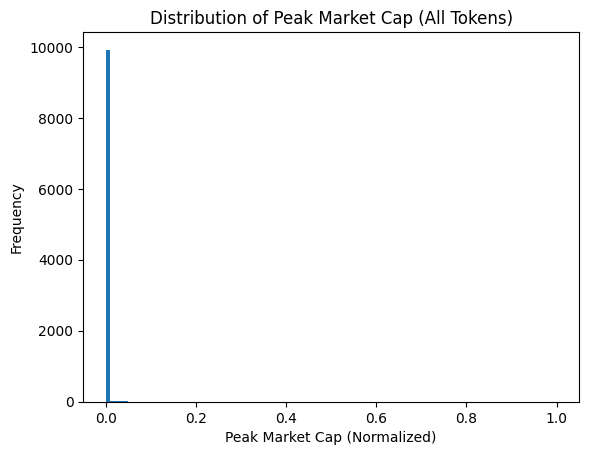

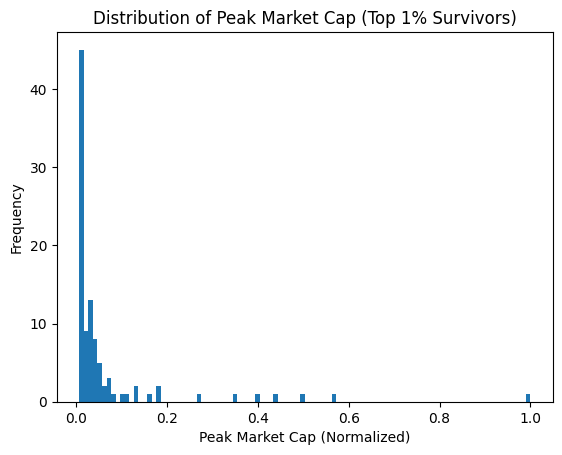

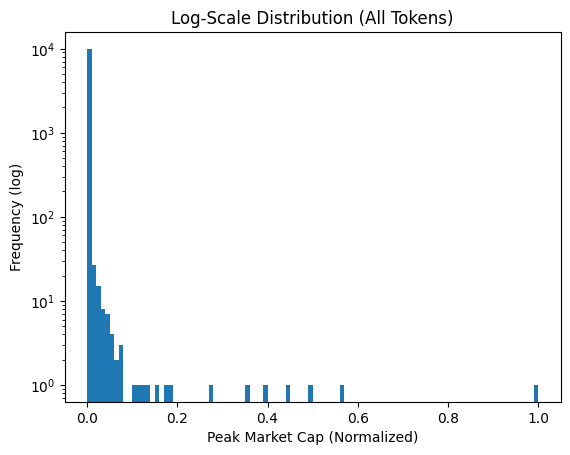

In [1]:
# ==============================
# Survivorship Bias Simulation
# Crypto Market Power-Law Model
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Parameters --------
np.random.seed(42)
N_TOKENS = 10000
PARETO_ALPHA = 2.5   # shape parameter (tail thickness)

# -------- Generate Power-Law Distribution --------
# Pareto distribution (heavy tail)
raw = np.random.pareto(PARETO_ALPHA, N_TOKENS)

# Normalize and exaggerate skew so ~99% near zero
market_caps = raw / raw.max()
market_caps = market_caps ** 3   # increase inequality

# -------- Create DataFrames --------
df_all = pd.DataFrame({
    "token_id": np.arange(N_TOKENS),
    "peak_market_cap": market_caps
})

# Survivors = Top 1%
threshold = np.percentile(df_all["peak_market_cap"], 99)
df_survivors = df_all[df_all["peak_market_cap"] >= threshold].copy()

# -------- Evaluation --------
mean_all = df_all["peak_market_cap"].mean()
mean_survivors = df_survivors["peak_market_cap"].mean()
bias_multiplier = mean_survivors / mean_all

print("========== Survivorship Bias Results ==========")
print(f"Total Tokens: {len(df_all)}")
print(f"Survivors (Top 1%): {len(df_survivors)}")
print("-----------------------------------------------")
print(f"Mean Market Cap (All Tokens): {mean_all:.6f}")
print(f"Mean Market Cap (Top 1% Only): {mean_survivors:.6f}")
print(f"Survivorship Bias Multiplier: {bias_multiplier:.2f}x")

# -------- Visualization 1: All Tokens --------
plt.figure()
plt.hist(df_all["peak_market_cap"], bins=100)
plt.title("Distribution of Peak Market Cap (All Tokens)")
plt.xlabel("Peak Market Cap (Normalized)")
plt.ylabel("Frequency")
plt.show()

# -------- Visualization 2: Survivors Only --------
plt.figure()
plt.hist(df_survivors["peak_market_cap"], bins=100)
plt.title("Distribution of Peak Market Cap (Top 1% Survivors)")
plt.xlabel("Peak Market Cap (Normalized)")
plt.ylabel("Frequency")
plt.show()

# -------- Optional: Log-Scale View (More Realistic for Power Laws) --------
plt.figure()
plt.hist(df_all["peak_market_cap"], bins=100)
plt.yscale("log")
plt.title("Log-Scale Distribution (All Tokens)")
plt.xlabel("Peak Market Cap (Normalized)")
plt.ylabel("Frequency (log)")
plt.show()
